# Leaf Segmentation: Color Space PCA and Otsu Comparison

This notebook provides a comparison of leaf segmentation quality across three distinct color spaces, separated into individual cells, without using polarity correction:
1. **RGB** (Red, Green, Blue)
2. **CIELAB** (Lightness $L^*$, Green-Red $a^*$, Blue-Yellow $b^*$)
3. **HSV** (Hue, Saturation, Value)

### Pipeline for each Color Space:
- **Channel Stacking**: Stack the 3 channels of the space into a 3D feature representation per pixel.
- **Channel Standardization**: Center each channel to zero mean and scale to unit variance to prevent lightness dominance in PCA.
- **PCA Projection**: Compute the first Principal Component (PC1) using `cv2.PCACompute2` to capture the axis of maximum variance.
- **Otsu's Thresholding**: Adaptively calculate a global threshold to binarize the PC1 projection.
- **Morphological Cleaning**: Apply Opening followed by Closing using a 5x5 elliptical kernel to remove small background noise and fill leaf holes.
- **Geometric Contour Filtering**: Exclude background troughs and gulley edges by checking aspect ratio, width-spanning boundaries, and area limits.
- **Contour Drawing**: Overlay the final refined contours onto the original image.

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

%matplotlib inline

### Step 1: Load the Representative Image

We load a representative image from the `veg_2` category (`leaf-image/veg_2/IMG_7995.JPG`).

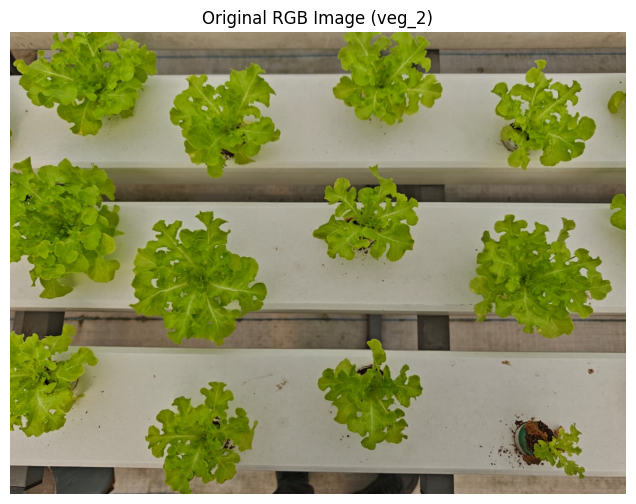

In [ ]:
img_path = 'leaf-image/veg_3/IMG_799.JPG'

img_bgr = cv2.imread(img_path)
if img_bgr is None:
    raise FileNotFoundError(f"Could not locate the image at: {img_path}")

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 6))
plt.imshow(img_rgb)
plt.title("Original RGB Image (veg_2)")
plt.axis('off')
plt.show()

### Step 2: RGB Color Space Pipeline

Processing Color Space: Optimized Feature Map
[Feature Map] Otsu threshold value: 112.0


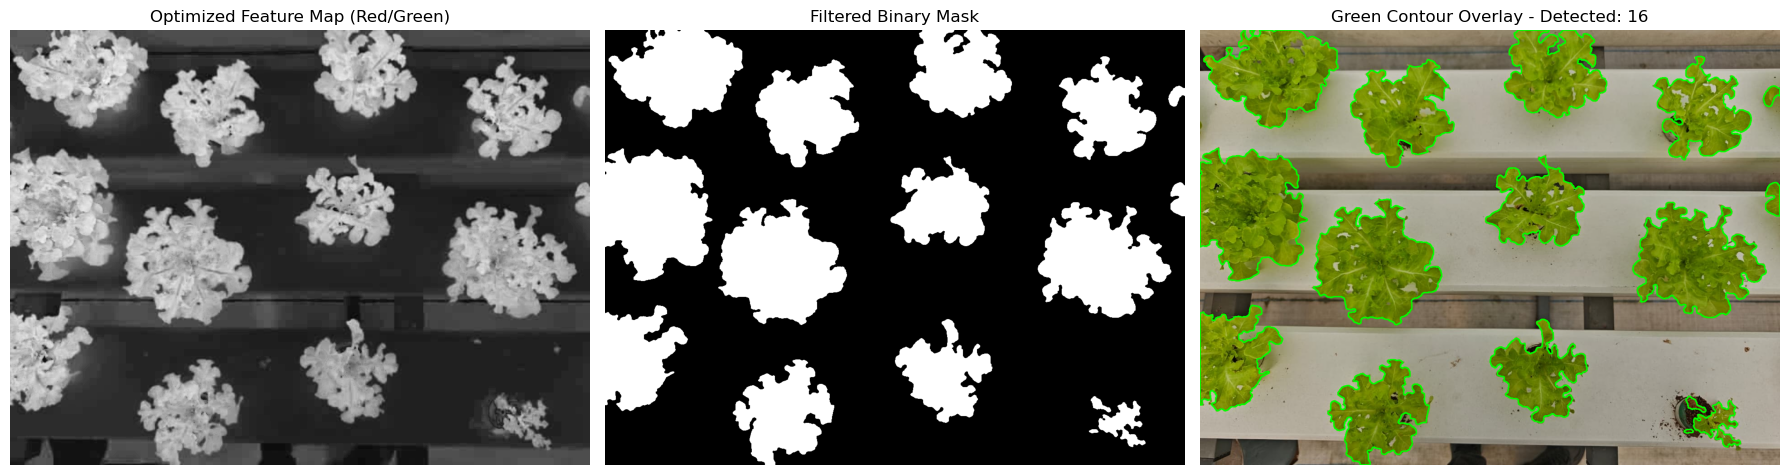

In [54]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

print("========================================")
print("Processing Color Space: Optimized Feature Map")
print("========================================")

# 1. Direct Vectorized Feature Extraction (Replaces PCA)
# Convert to float to avoid uint8 underflow/overflow
R = img_rgb[:, :, 0].astype(np.float32)
G = img_rgb[:, :, 1].astype(np.float32)
B = img_rgb[:, :, 2].astype(np.float32)

# Create a single channel map highlighting BOTH red and green organic matter
# This removes background tray dominance instantly without heavy PCA overhead
feature_map = cv2.max(2 * G - R - B, 2 * R - G - B)

# Scale to 0-255 safely
f_min, f_max = feature_map.min(), feature_map.max()
pc1_scaled = np.uint8(255 * (feature_map - f_min) / (f_max - f_min + 1e-8))

# 2. Apply Otsu's Thresholding
ret, thresh = cv2.threshold(pc1_scaled, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
print(f"[Feature Map] Otsu threshold value: {ret}")

# Quick Polarity Check (Ensures plants are ALWAYS white, background ALWAYS black)
h, w = thresh.shape
corners = [thresh[0, 0], thresh[0, w-1], thresh[h-1, 0], thresh[h-1, w-1]]
if np.mean(corners) > 127:
    thresh = cv2.bitwise_not(thresh)

# 3. Morphological Cleaning
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
cleaned = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)
cleaned = cv2.morphologyEx(cleaned, cv2.MORPH_CLOSE, kernel)

# 4. Geometric Contour Filtering
contours, _ = cv2.findContours(cleaned, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
filtered_mask = np.zeros_like(cleaned)

for cnt in contours:
    area = cv2.contourArea(cnt)
    if 100 <= area <= 150000:
        x, y, w_box, h_box = cv2.boundingRect(cnt)
        aspect_ratio = float(w_box) / h_box
        
        # Eliminate structural frame lines or wide conveyor belt artifacts
        if w_box < 0.8 * w and 0.25 <= aspect_ratio <= 4.0:
            cv2.drawContours(filtered_mask, [cnt], -1, 255, -1)

# Extract final filtered contours for drawing
final_contours, _ = cv2.findContours(filtered_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Draw contours on a clean copy of the original RGB image
img_contour = img_rgb.copy()
cv2.drawContours(img_contour, final_contours, -1, (0, 255, 0), 2)

# 5. Plot step results side-by-side
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Panel 1: The customized 1D feature representation
axes[0].imshow(pc1_scaled, cmap='gray')
axes[0].set_title("Optimized Feature Map (Red/Green)")
axes[0].axis('off')

# Panel 2: The cleaned, post-processed binary mask
axes[1].imshow(filtered_mask, cmap='gray')
axes[1].set_title("Filtered Binary Mask")
axes[1].axis('off')

# Panel 3: Green contours overlaid on your original image
axes[2].imshow(img_contour)
axes[2].set_title(f"Green Contour Overlay - Detected: {len(final_contours)}")
axes[2].axis('off')

plt.tight_layout()
plt.show()

### Step 3: CIELAB Color Space Pipeline

Processing Color Space: CIELAB


[CIELAB] Otsu threshold value: 131.0


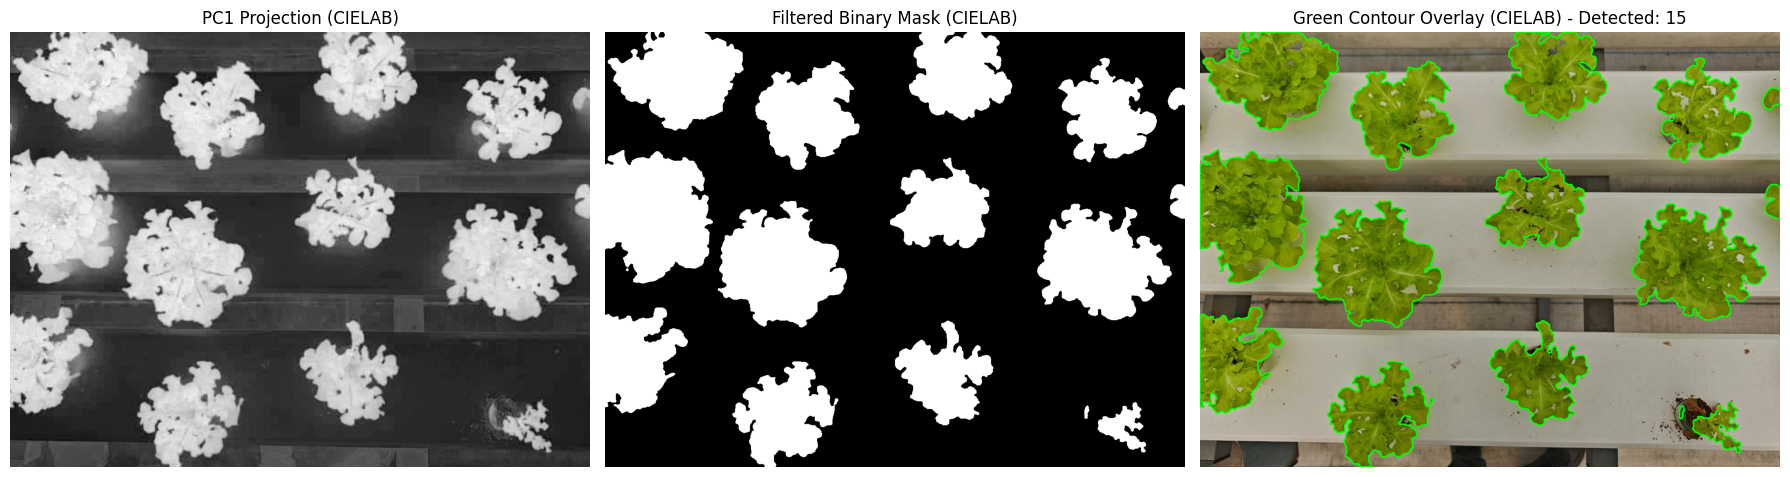

In [4]:
print("========================================")
print("Processing Color Space: CIELAB")
print("========================================")

# 1. Convert to CIELAB and split channels
img_lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2Lab)
l, a, b_lab = cv2.split(img_lab)

# 2. Standardize channels before PCA to prevent lightness scale dominance
flats = []
for ch in (l, a, b_lab):
    ch_f = ch.astype(np.float32)
    std = ch_f.std()
    ch_norm = (ch_f - ch_f.mean()) / (std if std > 1e-8 else 1.0)
    flats.append(ch_norm.reshape(-1, 1))
features = np.hstack(flats)

# 3. Run PCA
mean, eigenvectors, eigenvalues = cv2.PCACompute2(features, mean=None)
projected = cv2.PCAProject(features, mean, eigenvectors)
pc1 = projected[:, 0].reshape(l.shape)

# Scale to 0-255 (No Polarity Correction)
pc1_min = pc1.min()
pc1_max = pc1.max()
pc1_scaled = np.uint8(255 * (pc1 - pc1_min) / (pc1_max - pc1_min + 1e-8))

# 4. Apply Otsu's Thresholding
ret, thresh = cv2.threshold(pc1_scaled, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
print(f"[CIELAB] Otsu threshold value: {ret}")

# 5. Morphological Cleaning
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
cleaned = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)
cleaned = cv2.morphologyEx(cleaned, cv2.MORPH_CLOSE, kernel)

# 6. Post-processing: Geometric Contour Filtering
contours, _ = cv2.findContours(cleaned, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
filtered_mask = np.zeros_like(cleaned)
for cnt in contours:
    area = cv2.contourArea(cnt)
    if area < 100 or area > 150000:
        continue
    x, y, w, h = cv2.boundingRect(cnt)
    aspect_ratio = float(w) / h
    if w > 0.8 * img_rgb.shape[1] or aspect_ratio > 4.0 or aspect_ratio < 0.25:
        continue
    cv2.drawContours(filtered_mask, [cnt], -1, 255, -1)
cleaned = filtered_mask

# Extract final filtered contours
final_contours, _ = cv2.findContours(cleaned, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Draw contours on RGB image copy
img_contour = img_rgb.copy()
cv2.drawContours(img_contour, final_contours, -1, (0, 255, 0), 2)

# Plot step results side-by-side
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(pc1_scaled, cmap='gray')
axes[0].set_title("PC1 Projection (CIELAB)")
axes[0].axis('off')

axes[1].imshow(cleaned, cmap='gray')
axes[1].set_title("Filtered Binary Mask (CIELAB)")
axes[1].axis('off')

axes[2].imshow(img_contour)
axes[2].set_title(f"Green Contour Overlay (CIELAB) - Detected: {len(final_contours)}")
axes[2].axis('off')

plt.tight_layout()
plt.show()

### Step 4: HSV Color Space Pipeline

Processing Color Space: HSV


[HSV] Otsu threshold value: 55.0


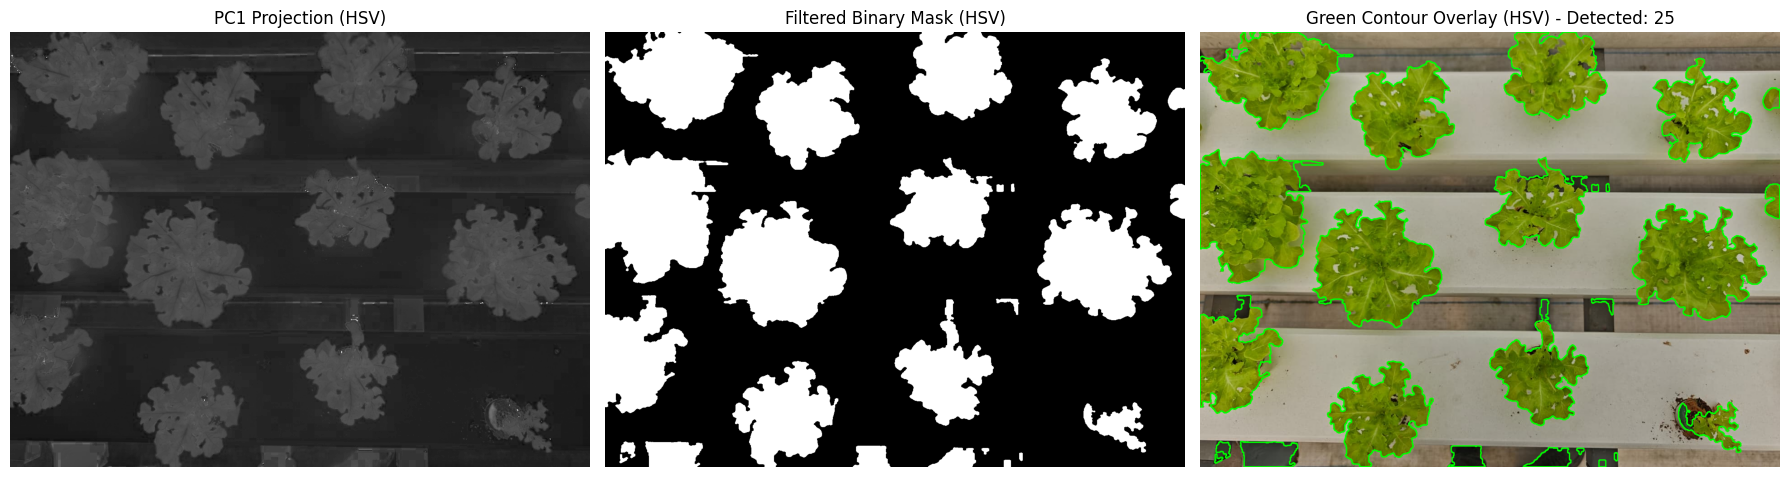

In [5]:
print("========================================")
print("Processing Color Space: HSV")
print("========================================")

# 1. Convert to HSV and split channels
img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
h, s, v = cv2.split(img_hsv)

# 2. Standardize channels before PCA to prevent lightness scale dominance
flats = []
for ch in (h, s, v):
    ch_f = ch.astype(np.float32)
    std = ch_f.std()
    ch_norm = (ch_f - ch_f.mean()) / (std if std > 1e-8 else 1.0)
    flats.append(ch_norm.reshape(-1, 1))
features = np.hstack(flats)

# 3. Run PCA
mean, eigenvectors, eigenvalues = cv2.PCACompute2(features, mean=None)
projected = cv2.PCAProject(features, mean, eigenvectors)
pc1 = projected[:, 0].reshape(h.shape)

# Scale to 0-255 (No Polarity Correction)
pc1_min = pc1.min()
pc1_max = pc1.max()
pc1_scaled = np.uint8(255 * (pc1 - pc1_min) / (pc1_max - pc1_min + 1e-8))

# 4. Apply Otsu's Thresholding
ret, thresh = cv2.threshold(pc1_scaled, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
print(f"[HSV] Otsu threshold value: {ret}")

# 5. Morphological Cleaning
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
cleaned = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)
cleaned = cv2.morphologyEx(cleaned, cv2.MORPH_CLOSE, kernel)

# 6. Post-processing: Geometric Contour Filtering
contours, _ = cv2.findContours(cleaned, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
filtered_mask = np.zeros_like(cleaned)
for cnt in contours:
    area = cv2.contourArea(cnt)
    if area < 100 or area > 150000:
        continue
    x, y, w, h = cv2.boundingRect(cnt)
    aspect_ratio = float(w) / h
    if w > 0.8 * img_rgb.shape[1] or aspect_ratio > 4.0 or aspect_ratio < 0.25:
        continue
    cv2.drawContours(filtered_mask, [cnt], -1, 255, -1)
cleaned = filtered_mask

# Extract final filtered contours
final_contours, _ = cv2.findContours(cleaned, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Draw contours on RGB image copy
img_contour = img_rgb.copy()
cv2.drawContours(img_contour, final_contours, -1, (0, 255, 0), 2)

# Plot step results side-by-side
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(pc1_scaled, cmap='gray')
axes[0].set_title("PC1 Projection (HSV)")
axes[0].axis('off')

axes[1].imshow(cleaned, cmap='gray')
axes[1].set_title("Filtered Binary Mask (HSV)")
axes[1].axis('off')

axes[2].imshow(img_contour)
axes[2].set_title(f"Green Contour Overlay (HSV) - Detected: {len(final_contours)}")
axes[2].axis('off')

plt.tight_layout()
plt.show()